<div style="font-family:'Times New Roman';">

En este ejemplo, recuperaremos datos MS/MS de un archivo MGF y los compararemos con la información de identificación obtenida de un archivo pepXML. Compararemos el espectro MS/MS del archivo con el espectro teórico de un péptido asignado a este espectro por el motor de búsqueda.

También necesitaremos el y el , pero el script los descargará automáticamente.example MGF fileexample pepXML file

El archivo MGF contiene un único espectro MS/MS. Este espectro se obtiene de la base de datos SwedCAD de espectros MS/MS anotados . El archivo pepXML se obtuvo ejecutando X!Tandem con el archivo MGF y convirtiendo los resultados a pepXML con la herramienta Tandem2XML de TPP .

Comencemos con la importación de los módulos.

In [9]:
from pyteomics import mgf, pepxml, mass, pylab_aux
import os
from urllib.request import urlopen, Request
import pylab

<div style="font-family:'Times New Roman';">

Luego, descargaremos los archivos, si es necesario. Ejecútalo si estás siguiendo el proceso en tu equipo local. De lo contrario, omite esta parte y supongamos que tenemos example.mgf y example.pep.xml en el directorio de trabajo.

In [10]:
for fname in ('mgf', 'pep.xml'):
    if not os.path.isfile('example.' + fname):
        headers = {'User-Agent': 'Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.11 (KHTML, like Gecko) Chrome/23.0.1271.64 Safari/537.11'}
        url = 'http://pyteomics.readthedocs.io/en/latest/_static/example.' + fname
        request = Request(url, None, headers)
        target_name = 'example.' + fname
        with urlopen(request) as response, open(target_name, 'wb') as fout:
            print('Downloading ' + target_name + '...')
            fout.write(response.read())

<div style="font-family:'Times New Roman';">

¡Listo! Primero, leamos el espectro único y el PSM correspondiente de los archivos.




In [11]:
with mgf.read('example.mgf') as spectra, pepxml.read('example.pep.xml') as psms:
    spectrum = next(spectra)
    psm = next(psms)

<div style="font-family:'Times New Roman';">

Supongamos que solo queremos visualizar el espectro de MGF. ¡Es fácil!

En este punto, se creará una figura que se verá así:

<Axes: title={'center': 'Experimental spectrum GPAAIQK'}, xlabel='m/z', ylabel='intensity'>

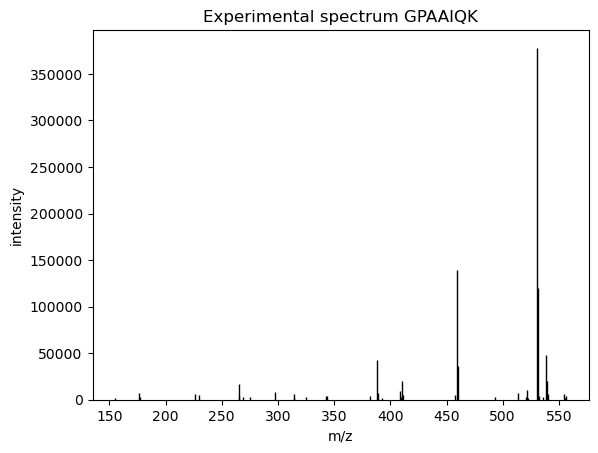

In [12]:
pylab.figure()
pylab_aux.plot_spectrum(spectrum, title="Experimental spectrum " + spectrum['params']['title'])

<div style="font-family:'Times New Roman';">

Es posible que no veas la cifra hasta que llames pylab.show()al final, dependiendo de tu entorno.

¿Qué pasa si queremos ver qué picos coinciden realmente con el péptido asignado? Esto es lo que llamamos anotación espectral y también es fácil de hacer:



<Axes: title={'center': 'Annotated spectrum GPAAIQK'}, xlabel='m/z', ylabel='intensity'>

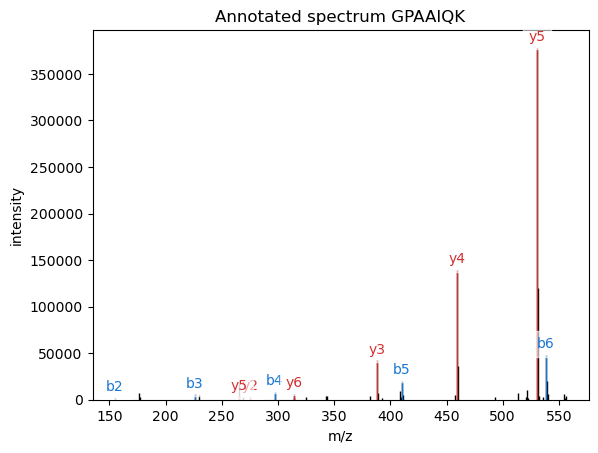

In [13]:
pylab.figure()
pylab_aux.annotate_spectrum(spectrum, psm['search_hit'][0]['peptide'],
    title='Annotated spectrum ' + psm['search_hit'][0]['peptide'],
    maxcharge=psm['assumed_charge'])

<div style="font-family:'Times New Roman';">

Como puede ver, pylab_aux.annotate_spectrum()se necesita un espectro y una secuencia de péptidos. Consulte el ejemplo 4 para obtener más información sobre la anotación de espectros.

Ahora, supongamos que queremos algo más: ver todos los picos teóricos y observados. No existe una función disponible para esto, así que tendremos que implementar el cálculo de las masas de los fragmentos. Usaremos pyteomics.mass.fast_mass():

In [14]:
def fragments(peptide, types=('b', 'y'), maxcharge=1):
    """
    The function generates all possible m/z for fragments of types
    `types` and of charges from 1 to `maxharge`.
    """
    for i in range(1, len(peptide)):
        for ion_type in types:
            for charge in range(1, maxcharge+1):
                if ion_type[0] in 'abc':
                    yield mass.fast_mass(
                            peptide[:i], ion_type=ion_type, charge=charge)
                else:
                    yield mass.fast_mass(
                            peptide[i:], ion_type=ion_type, charge=charge)

<div style="font-family:'Times New Roman';">

Entonces, el bucle externo es sobre los “sitios de fragmentación”, el siguiente es sobre los tipos de iones, luego sobre las cargas y, por último, sobre dos partes de la secuencia (C- y N-terminal).

Usaremos la misma función pylab_aux.plot_spectrum()para representar gráficamente los picos experimentales y teóricos en la misma figura. Para ello, necesitamos simular un "espectro" teórico en el formato que la función espera, que es un diccionario con dos claves principales: "matriz m/z" y "matriz de intensidad". No tenemos intensidades predichas, por lo que usaremos la intensidad máxima del espectro experimental:

In [15]:
fragment_list = list(fragments(psm['search_hit'][0]['peptide'], maxcharge=psm['assumed_charge']))
theor_spectrum = {'m/z array': fragment_list, 'intensity array': [spectrum['intensity array'].max()] * len(fragment_list)}

<div style="font-family:'Times New Roman';">

El resto es fácil. Grafica dos espectros (y modifícalos para que tengan dos colores diferentes) y luego llama pylab.show() para ver todas las figuras:

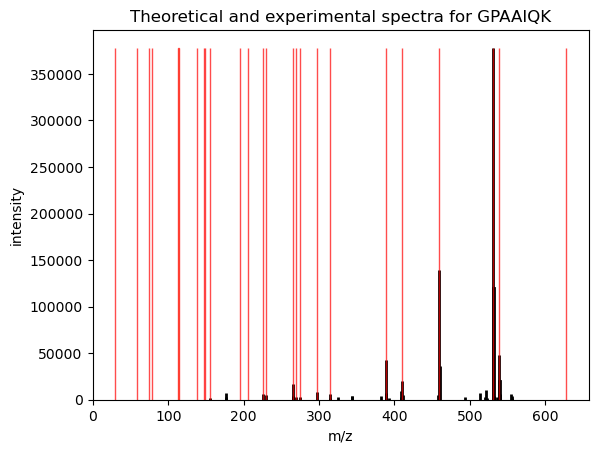

In [16]:
pylab.figure()
pylab.title('Theoretical and experimental spectra for ' + psm['search_hit'][0]['peptide'])
pylab_aux.plot_spectrum(spectrum, width=0.1, linewidth=2, edgecolor='black')
pylab_aux.plot_spectrum(theor_spectrum, width=0.1, edgecolor='red', alpha=0.7)
pylab.show()

<div style="font-family:'Times New Roman';">

Eso es, como puedes ver, los picos más intensos del espectro coinciden de hecho con el espectro teórico.

